# How many visual variables can we manage in a graph?

In this exercise you will explore how many data variables can be represented simultaneously in a single scatterplot – by making use of different **visual variables** (also called visual channels).

**Submission:** Upload this notebook, fully completed and executed (all cells run), to Moodle.

**Note on AI tools:** If you used any AI tools, document your prompts in the cell provided at the end. Every line of code must include a comment demonstrating that you understand it.

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib as mpl

%config InlineBackend.figure_format = 'svg'

MTCARS_URL = 'https://drive.switch.ch/index.php/s/PBJYIfcEkUQ64d1/download'
df = pd.read_csv(MTCARS_URL)
df.head()

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


---
## Task 1: Assign variable types

Assign the correct variable type/scale of measurement to each attribute in the dataset.

**Allowed values:** `'nominal'`, `'ordinal'`, `'continuous'`

Replace all `'???'` with your answer.

In [4]:
variable_types = {
    'model': 'nominal',   # name of the car model
    'mpg': 'continuous',   # fuel efficiency (miles per gallon)
    'cyl': 'ordinal',   # number of cylinders (4, 6, 8)
    'disp': 'continuous',   # displacement (cubic inches)
    'hp': 'continuous',   # horsepower
    'drat': 'continuous',   # rear axle ratio
    'wt': 'continuous',   # weight (1000 lbs)
    'qsec': 'continuous',   # quarter-mile time (seconds)
    'vs': 'nominal',   # engine shape (0=V-shaped, 1=straight)
    'am': 'nominal',   # transmission (0=automatic, 1=manual)
    'gear': 'ordinal',   # number of forward gears
    'carb': 'ordinal',   # number of carburetors
}



---
## Task 2: Scatterplot – fuel efficiency vs. displacement

Create a scatterplot with:
- **x-axis:** displacement (`disp`)
- **y-axis:** fuel efficiency (`mpg`)

Use the **object-oriented Matplotlib pattern** (`fig, ax = plt.subplots()`).
Label both axes.

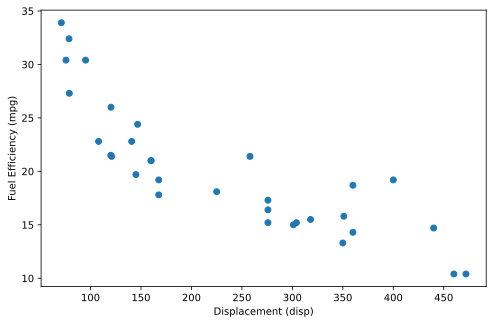

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

# Scatterplot
ax.scatter(df['disp'], df['mpg'])

# Achsen beschriften
ax.set_xlabel('Displacement (disp)')
ax.set_ylabel('Fuel Efficiency (mpg)')

plt.show()

---
## Task 3: Add more visual variables

How many additional data variables can you fit into the plot?

Use visual variables such as color, size, shape, transparency, or text labels.
Extend the plot from Task 2 – or create a new plot in this cell.

Then document which visual variables you used.

**Allowed values in the list:** `'color'`, `'size'`, `'shape'`, `'transparency'`, `'text_label'`

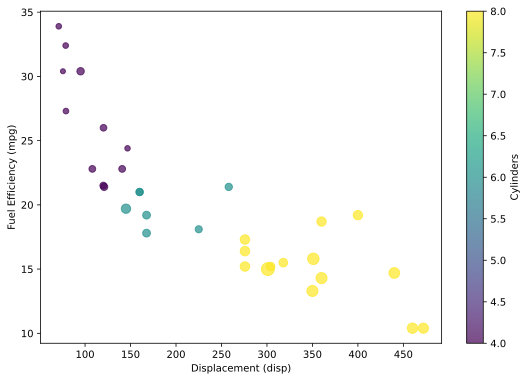

In [6]:
fig2, ax2 = plt.subplots(figsize=(9, 6))

# Scatterplot mit zusätzlichen visuellen Variablen
scatter = ax2.scatter(
    df['disp'], 
    df['mpg'],
    c=df['cyl'],          # color → Anzahl Zylinder
    s=df['hp'] * 0.5,     # size → horsepower (skaliert)
    alpha=0.7             # transparency
)

# Achsen
ax2.set_xlabel('Displacement (disp)')
ax2.set_ylabel('Fuel Efficiency (mpg)')

# Optional: Colorbar
plt.colorbar(scatter, ax=ax2, label='Cylinders')

plt.show()

In [8]:
# Which visual variables did you use in addition to x- and y-position?
#Extend the list – at least one entry required.
# e.g. ['color', 'size']

visual_variables_used = ['color', 'size', 'transparency']

---
## Reflection

Answer briefly (2–4 sentences) in the cell below:
- Which visual variables work well, and which do not?
- At what point does the plot become unreadable?

Color and size work well because they allow easy comparison between data points without cluttering the plot. Transparency also helps when points overlap. However, adding too many variables (like shape and text labels together) quickly makes the plot hard to read. The plot becomes unreadable when multiple encodings compete for attention and labels start to overlap.

---
## AI tool documentation (if used)

If you used any AI tools (e.g. ChatGPT, Claude, Copilot), list your prompts here.

I used ChatGPT to assist with implementing a scatterplot using Matplotlib. I asked for help on extending the plot with additional visual variables such as color, size, and transparency, and how to properly document these choices. ChatGPT also helped refine short written answers for the reflection questions.

---
## ✅ Self-test (do not modify)

This cell runs an automatic self-test. Execute it before submitting – all checks should be green.

In [9]:
# ==============================================================
# SELF-TEST (DO NOT MODIFY) – DO NOT MODIFY
# ==============================================================
import json

_errors = []
_warnings = []

# --- Task 1 ---
allowed_types = {'nominal', 'ordinal', 'continuous'}
expected_keys = {'model','mpg','cyl','disp','hp','drat','wt','qsec','vs','am','gear','carb'}

if not isinstance(variable_types, dict):
    _errors.append('T1: variable_types must be a dict')
else:
    missing = expected_keys - set(variable_types.keys())
    if missing:
        _errors.append('T1: Missing keys: {}'.format(missing))
    unanswered = [k for k,v in variable_types.items() if v == '???']
    if unanswered:
        _errors.append('T1: Not yet answered: {}'.format(unanswered))
    invalid = [k for k,v in variable_types.items() if v not in allowed_types]
    if invalid and not unanswered:
        _errors.append('T1: Invalid values for: {} (allowed: {})'.format(invalid, allowed_types))

# --- Task 2 ---
try:
    _xlabel = ax.get_xlabel()
    _ylabel = ax.get_ylabel()
    _npts   = sum(len(c.get_offsets()) for c in ax.collections)
    if not _xlabel:
        _warnings.append('T2: x-axis has no label')
    if not _ylabel:
        _warnings.append('T2: y-axis has no label')
    if _npts == 0:
        _errors.append('T2: No data points found in plot')
except NameError:
    _errors.append('T2: fig/ax not defined – run Task 2 first')
    _xlabel, _ylabel, _npts = '', '', 0

# --- Task 3 ---
allowed_vis = {'color', 'size', 'shape', 'transparency', 'text_label'}
if not isinstance(visual_variables_used, list):
    _errors.append('T3: visual_variables_used must be a list')
elif len(visual_variables_used) == 0:
    _errors.append('T3: List is empty – add at least one visual variable')
else:
    invalid_vis = set(visual_variables_used) - allowed_vis
    if invalid_vis:
        _errors.append('T3: Invalid entries: {}'.format(invalid_vis))

# --- Output ---
print('=' * 50)
if _errors:
    for err in _errors:
        print(f'❌ {err}')
else:
    print('✅ All required fields completed and formally correct')
for w in _warnings:
    print(f'⚠️  {w}')
print('=' * 50)

# --- Export for automatic grading ---
_export = {
    'variable_types': variable_types,
    'xlabel': _xlabel,
    'ylabel': _ylabel,
    'n_points': _npts,
    'visual_variables_used': visual_variables_used,
}
print('__GRADING_EXPORT__')
print(json.dumps(_export))


✅ All required fields completed and formally correct
__GRADING_EXPORT__
{"variable_types": {"model": "nominal", "mpg": "continuous", "cyl": "ordinal", "disp": "continuous", "hp": "continuous", "drat": "continuous", "wt": "continuous", "qsec": "continuous", "vs": "nominal", "am": "nominal", "gear": "ordinal", "carb": "ordinal"}, "xlabel": "Displacement (disp)", "ylabel": "Fuel Efficiency (mpg)", "n_points": 32, "visual_variables_used": ["color", "size", "transparency"]}
